In [6]:
def fact(n):
    fact=1
    for i in range(1,(n+1)):
         fact=fact*i
    return fact
fact(5)

120

In [7]:
import numpy as np
l=[1,2,3,4,5]
n=np.array(l)
print(type(n))
print(n.ndim)
print(n.shape)
print(n.size)

<class 'numpy.ndarray'>
1
(5,)
5


In [19]:
import pandas as pd
stock={'Name':['RAM','REGISTER','KEYBOARD','MOUSE','FLASH','DRIVE'],
       'Price':[100,1200,20000,3000,1200,11000],
       'Quantity':[10,12,2,3,12,11]
      }
df=pd.DataFrame(stock)
df.to_csv('stock.csv',index=False)
print(df.head(3))
print(df.tail(4))

       Name  Price  Quantity
0       RAM    100        10
1  REGISTER   1200        12
2  KEYBOARD  20000         2
       Name  Price  Quantity
2  KEYBOARD  20000         2
3     MOUSE   3000         3
4     FLASH   1200        12
5     DRIVE  11000        11


In [18]:
import numpy as np
arr=np.arange(20,29).reshape(3,3)
print(arr)
print("Third row:",arr[2:])
print("Second col:",arr[:,1])

[[20 21 22]
 [23 24 25]
 [26 27 28]]
Third row: [[26 27 28]]
Second col: [21 24 27]


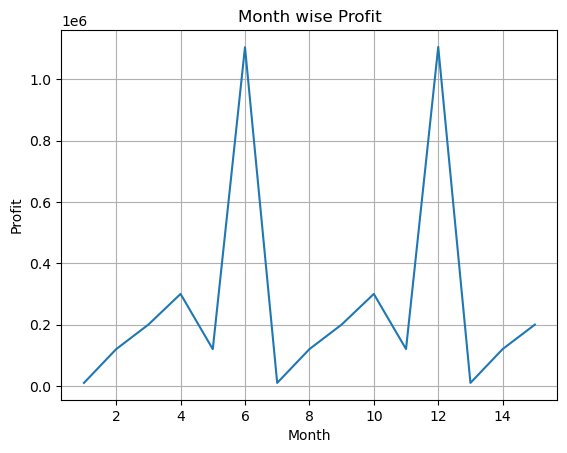

In [23]:
import matplotlib.pyplot as plt
stock = {
    'Month': [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    'Profit': [10000,120000,200000,300010,120000,1104000,
               10000,120070,200080,300005,120400,1105000,
               10040,120300,200020]
}
plt.plot(stock['Month'], stock['Profit'])
plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Month wise Profit")
plt.grid(True)
plt.show()


In [3]:
import numpy as np
x=np.array([
    [1,2],[2,1],[3,4],
    [5,7],[6,8],[7,6],
    [8,5],[4,3]
])
print(x)

[[1 2]
 [2 1]
 [3 4]
 [5 7]
 [6 8]
 [7 6]
 [8 5]
 [4 3]]


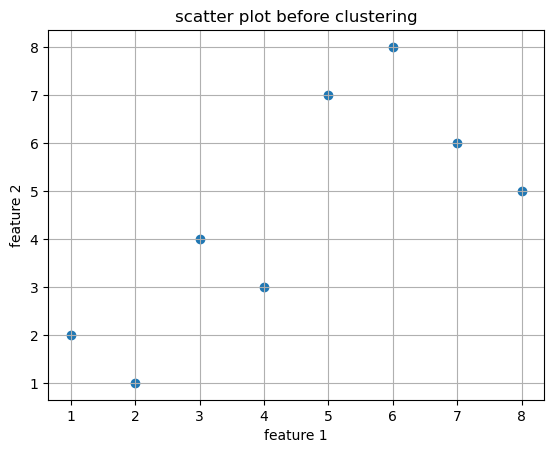

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1])
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("scatter plot before clustering")
plt.grid(True)
plt.show()

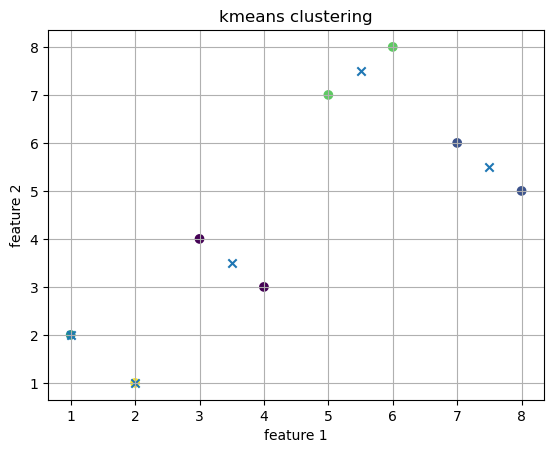

In [5]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=5,n_init='auto',random_state=42)
labels=kmeans.fit_predict(x)
plt.scatter(x[:,0],x[:,1],c=labels)
plt.scatter(
           kmeans.cluster_centers_[:,0],
           kmeans.cluster_centers_[:,1],
           marker='x'
)
plt.title("kmeans clustering")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.grid(True)
plt.show()

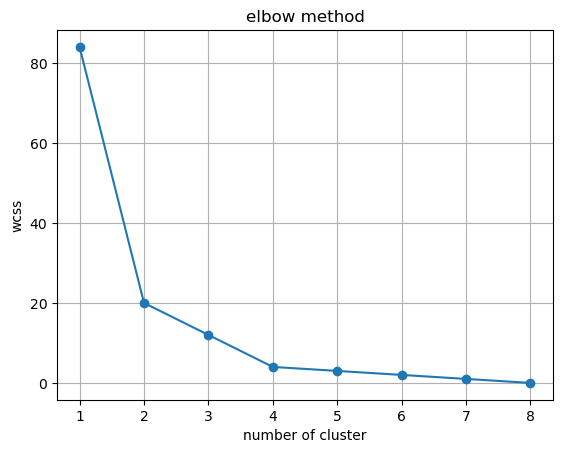

In [6]:
wcss=[]
for k in range(1,9):
    km=KMeans(n_clusters=k,n_init='auto',random_state=42)
    km.fit(x)
    wcss.append(km.inertia_)
plt.plot(range(1,9),wcss,marker='o')
plt.xlabel("number of cluster")
plt.ylabel("wcss")
plt.title("elbow method")
plt.grid(True)
plt.show()

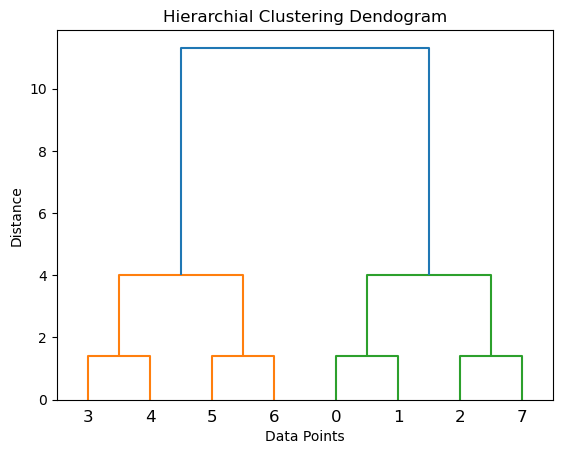

In [9]:
from scipy.cluster.hierarchy import dendrogram,linkage
z=linkage(X,method='ward')
dendrogram(z)
plt.title("Hierarchial Clustering Dendogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

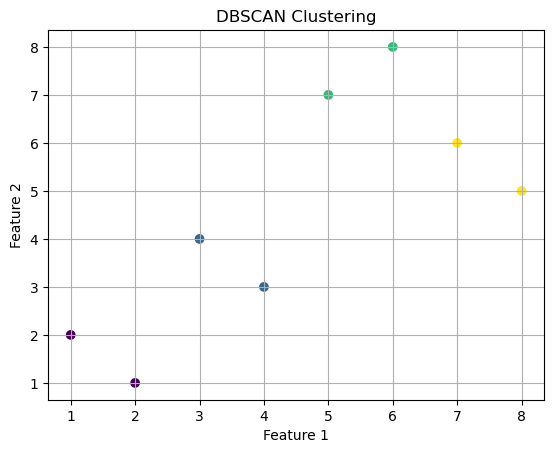

In [11]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=1.5,min_samples=2)
db_labels=dbscan.fit_predict(x)
plt.scatter(x[:,0],x[:,1],c=db_labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")
plt.grid(True)
plt.show()

In [12]:
pip install scikit-learn-extra

Note: you may need to restart the kernel to use updated packages.


/home/iter/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


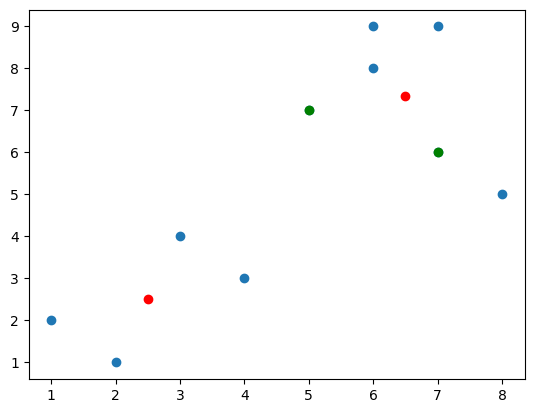

Centroids: [[2.5        2.5       ]
 [6.5        7.33333333]]
Medoids: [[5. 7.]
 [7. 6.]]


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# Data
data = [[1,2],[2,1],[3,4],[5,7],[6,8],[7,6],[8,5],[4,3],[6,9],[7,9]]

# Correct DataFrame creation
df = pd.DataFrame(data, columns=['x','y'])

#KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df)
centroids = kmeans.cluster_centers_
#KMedoids
kmedoid = KMedoids(n_clusters=2, random_state=42)
kmedoid.fit(df)
medoids = kmedoid.cluster_centers_
plt.scatter(df['x'], df['y'], label='Data')
plt.scatter(centroids[:,0], centroids[:,1], color='red')
plt.scatter(medoids[:,0], medoids[:,1], color='green')
plt.show()
print("Centroids:", centroids)
print("Medoids:", medoids)

In [13]:
transactions=[
    {"Bread","Milk","Egg","Butter","Salt","Apple"},
    {"Bread","Milk","Egg","Apple"},
    {"Bread","Milk","Butter","Apple"},
    {"Milk","Egg","Butter","Apple"},
    {"Bread","Egg","Salt"},
    {"Bread","Milk","Egg","Apple"}
]
print(transactions)

[{'Egg', 'Butter', 'Salt', 'Bread', 'Apple', 'Milk'}, {'Egg', 'Apple', 'Bread', 'Milk'}, {'Butter', 'Apple', 'Bread', 'Milk'}, {'Butter', 'Egg', 'Apple', 'Milk'}, {'Egg', 'Salt', 'Bread'}, {'Egg', 'Apple', 'Bread', 'Milk'}]


In [14]:
import pandas as pd
items=sorted(set().union(*transactions))
data=[]
for t in transactions:
    row={item:(1 if item in t else 0) for item in items}
    data.append(row)
df=pd.DataFrame(data)
df.index=range(1,len(df)+1)
df.index.name="Transaction"
print(df)

             Apple  Bread  Butter  Egg  Milk  Salt
Transaction                                       
1                1      1       1    1     1     1
2                1      1       0    1     1     0
3                1      1       1    0     1     0
4                1      0       1    1     1     0
5                0      1       0    1     0     1
6                1      1       0    1     1     0


In [19]:
def support(itemset,transactions):
        return sum(1 for t in transactions if itemset.issubset(t))/len(transactions)
def confidence(x,y,transactions):
        return support(x.union(y),transactions)/support(x,transactions)
print("Supoort(bread):",support({"Bread"},transactions))
print("Confidence(Bread -> Milk):",confidence({"Bread"},{"Milk"},transactions))
# print("Confidence(Bread,Milk->Egg):",confidence({"Bread","Milk"},{"Egg"}))

Supoort(bread): 0.8333333333333334
Confidence(Bread->Milk): 0.7999999999999999


In [24]:
min_support=0.5
def support(itemset):
    return sum(1 for t in transactions if itemset.issubset(t))/len(transactions)
items=sorted(set().union(*transactions))
freq_1=[{i} for i in items if support({i})>=min_support]
print("Frequent 1-itemsets : ")
for i in freq_1:
    print(i,"Support = ",support(i))
    
from itertools import combinations
candidates_2=[set(c) for c in combinations([list(i)[0] for i in freq_1],2)]
freq_2=[c for c in candidates_2 if support(c) >= min_support]
print("\n Frequent 2-itemsets (after Apriori pruning) : ")
for c in freq_2:
    print(c,"Support = ",support(c))

Frequent 1-itemsets : 
{'Apple'} Support =  0.8333333333333334
{'Bread'} Support =  0.8333333333333334
{'Butter'} Support =  0.5
{'Egg'} Support =  0.8333333333333334
{'Milk'} Support =  0.8333333333333334

 Frequent 2-itemsets (after Apriori pruning) : 
{'Apple', 'Bread'} Support =  0.6666666666666666
{'Butter', 'Apple'} Support =  0.5
{'Egg', 'Apple'} Support =  0.6666666666666666
{'Apple', 'Milk'} Support =  0.8333333333333334
{'Egg', 'Bread'} Support =  0.6666666666666666
{'Bread', 'Milk'} Support =  0.6666666666666666
{'Butter', 'Milk'} Support =  0.5
{'Egg', 'Milk'} Support =  0.6666666666666666
